# Problem 3.7 – Shortest Path with Polygonal Obstacles

**Russell & Norvig, 3rd ed. Problem 3.7** (4th ed. 3.9)

> Consider the problem of finding the shortest path between two points on a plane that has convex polygonal obstacles (Figure 3.31). This is an idealization of the problem that a robot has to solve to navigate in a crowded environment.


---
## Part (a) — State Space Size and Number of Paths

**How many states are there?**

If the state space consists of *all positions (x, y) in the plane*, the number of states is
**infinite — uncountably so.** Any real-valued pair (x, y) is a valid state, giving the
cardinality of ℝ². Even bounding attention to the rectangle surrounding the obstacles does
not make the count finite, because between any two distinct real numbers there are infinitely
many others.

**How many paths are there to the goal?**

Again **infinitely many.** From any starting position S one can reach G via unlimited
trajectories: different straight-line detours, paths that bend at arbitrary intermediate
points, paths that loop, zigzag, or pass obstacles on different sides. The continuous
coordinate space places no bound on the number of geometrically distinct paths.

**Why this matters for search.** A naïve search over the full continuous plane is
intractable because the branching factor is infinite at every step. This motivates
restricting the state space to the finite vertex-based representation developed in Part (b).


---
## Part (b) — Good State Space: Polygon Vertices and the Visibility Graph

**Why must the shortest path bend only at polygon vertices?**

1. In open space (no obstacles) the shortest path between two points is a straight line — any
   detour increases length.
2. When an obstacle blocks the direct route, the path must go around it. Suppose the path
   bends at a point that lies on an obstacle *edge* but is not a *vertex*. We can "slide"
   that bend along the edge toward the nearer vertex; the triangle inequality guarantees the
   resulting path is no longer. Therefore every locally-optimal detour touches the boundary
   at a vertex.
3. Because all obstacles are *convex*, a path that touches a vertex can leave in a straight
   line without re-entering the obstacle.

**Good state space:** The set of all polygon vertices together with the start S and goal G.
Edges in the search graph connect pairs of nodes that can "see" each other — i.e., the
straight segment between them does not pass through any obstacle interior. This graph is
called the **visibility graph**.

**Size of the state space:** With 8 polygons containing 33 vertices in total, plus S and G,
the state space has **35 nodes**. The code below builds the visibility graph and confirms
this count, as well as the number of unobstructed sight-line edges.


In [1]:
import math, heapq, itertools
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
import matplotlib.patches as mpatches

# ── Geometry helpers ─────────────────────────────────────────────

def dist(a, b):
    """Euclidean distance between two (x, y) points."""
    return math.hypot(b[0]-a[0], b[1]-a[1])

def point_in_polygon(pt, polygon):
    """Ray-casting test: True if pt is strictly inside polygon."""
    x, y = pt
    inside = False
    j = len(polygon) - 1
    for i in range(len(polygon)):
        xi, yi = polygon[i]; xj, yj = polygon[j]
        if ((yi > y) != (yj > y)) and (x < (xj-xi)*(y-yi)/(yj-yi)+xi):
            inside = not inside
        j = i
    return inside

EPS = 1e-9

def proper_intersect(p1, p2, p3, p4):
    """True if segment p1-p2 crosses p3-p4 at a proper interior point (not at shared endpoints)."""
    if p1 == p3 or p1 == p4 or p2 == p3 or p2 == p4:
        return False
    def sign(x): return 1 if x>EPS else (-1 if x<-EPS else 0)
    def cross2(o,a,b): return (a[0]-o[0])*(b[1]-o[1])-(a[1]-o[1])*(b[0]-o[0])
    d1,d2 = sign(cross2(p3,p4,p1)), sign(cross2(p3,p4,p2))
    d3,d4 = sign(cross2(p1,p2,p3)), sign(cross2(p1,p2,p4))
    if d1*d2 < 0 and d3*d4 < 0: return True
    def between(p,a,b):
        return (min(a[0],b[0])-EPS<=p[0]<=max(a[0],b[0])+EPS and
                min(a[1],b[1])-EPS<=p[1]<=max(a[1],b[1])+EPS)
    if d1==0 and between(p1,p3,p4): return True
    if d2==0 and between(p2,p3,p4): return True
    if d3==0 and between(p3,p1,p2): return True
    if d4==0 and between(p4,p1,p2): return True
    return False

def segment_blocked(a, b, polygons):
    """True if segment a→b passes through the interior of any polygon."""
    for poly in polygons:
        n = len(poly)
        for i in range(n):
            if proper_intersect(a, b, poly[i], poly[(i+1)%n]):
                return True
    for t in [0.25, 0.5, 0.75]:
        mid = (a[0]+t*(b[0]-a[0]), a[1]+t*(b[1]-a[1]))
        for poly in polygons:
            if point_in_polygon(mid, poly):
                return True
    return False

# ── Scene definition (approximating Figure 3.31) ────────────────

POLYGONS = [
    [(1.0,6.5),(2.2,7.8),(3.5,7.8),(4.2,6.8),(3.0,5.5)],              # pentagon
    [(3.8,5.0),(4.8,7.2),(5.8,5.0)],                                   # triangle
    [(5.5,6.5),(6.8,7.5),(8.0,7.2),(7.5,5.8)],                        # quad
    [(8.5,5.5),(8.5,7.8),(11.0,7.8),(11.0,5.5)],                      # rectangle
    [(7.2,4.0),(8.5,5.2),(9.5,3.8)],                                   # small triangle
    [(11.2,5.5),(11.5,8.0),(12.5,7.8),(12.2,5.0)],                    # narrow quad
    [(3.0,2.5),(3.0,4.0),(7.0,4.0),(7.0,2.5)],                        # bottom rectangle
    [(9.0,1.5),(8.0,2.5),(8.0,4.0),(9.0,5.0),(10.5,5.0),(10.5,2.5)], # hexagon
]

START = (1.5, 3.2)   # S — bottom-left, outside all polygons
GOAL  = (13.0, 8.5)  # G — top-right

# ── Build visibility graph ───────────────────────────────────────

def build_visibility_graph(start, goal, polygons):
    nodes = [start, goal] + [v for poly in polygons for v in poly]
    graph = {v: {} for v in nodes}
    for a, b in itertools.combinations(nodes, 2):
        if not segment_blocked(a, b, polygons):
            d = dist(a, b)
            graph[a][b] = d
            graph[b][a] = d
    return graph

print("Building visibility graph ...")
vis_graph = build_visibility_graph(START, GOAL, POLYGONS)
n_nodes = len(vis_graph)
n_edges = sum(len(v) for v in vis_graph.values()) // 2

print(f"  Polygon vertices : {sum(len(p) for p in POLYGONS)}")
print(f"  + S and G        : 2")
print(f"  Total nodes      : {n_nodes}   (= state space size)")
print(f"  Visibility edges : {n_edges}")


Building visibility graph ...
  Polygon vertices : 33
  + S and G        : 2
  Total nodes      : 35   (= state space size)
  Visibility edges : 111


---
## Part (c) — Problem Formulation

The search problem is defined using the standard AIMA components:

| Component | Definition |
|---|---|
| **State** | An (x, y) tuple — one of the 35 visibility-graph nodes |
| **Initial state** | S = (1.5, 3.2) |
| **Goal state** | G = (13.0, 8.5) |
| **ACTIONS(s)** | Returns the list of vectors `(dx, dy, neighbour)` for every node reachable from `s` in the visibility graph. A node is reachable from `s` if the straight segment between them does not pass through any obstacle interior. Neighbours sharing an edge on the same polygon are always included (a polygon edge is never blocked by itself). |
| **RESULT(s, (dx, dy, neighbour))** | Returns `neighbour` — the destination vertex encoded in the action |
| **Path cost** | Cumulative Euclidean distance: `g(child) = g(parent) + dist(parent, child)` |
| **Heuristic h(s)** | Straight-line distance `dist(s, G)` — admissible (Euclidean ≤ true path cost through obstacles) and consistent (satisfies the triangle inequality), so A\* returns an optimal solution |

The `actions` method in the class below returns exactly `(dx, dy, neighbour)` triples, matching the description above.


In [2]:
class PolygonNavProblem:
    """
    Shortest-path navigation around convex polygonal obstacles.

    State     : (x, y) tuple — one of the visibility-graph nodes.
    Actions   : list of (dx, dy, neighbour) — direction vectors to visible nodes.
    Result    : destination vertex (the neighbour component of the action).
    Path cost : cumulative Euclidean distance.
    Heuristic : straight-line distance to goal (admissible and consistent).
    """

    def __init__(self, initial, goal, vis_graph):
        self.initial   = initial
        self.goal      = goal
        self.vis_graph = vis_graph

    def actions(self, state):
        """Return [(dx, dy, neighbour), ...] for every visible neighbour of state."""
        result = []
        for nbr in self.vis_graph[state]:
            dx = nbr[0] - state[0]
            dy = nbr[1] - state[1]
            result.append((dx, dy, nbr))
        return result

    def result(self, state, action):
        """Apply action: return the destination vertex."""
        _dx, _dy, neighbour = action
        return neighbour

    def path_cost(self, cost_so_far, state, action, next_state):
        return cost_so_far + dist(state, next_state)

    def goal_test(self, state):
        return state == self.goal

    def h(self, state):
        """Straight-line (Euclidean) distance to goal — admissible heuristic."""
        return dist(state, self.goal)


problem = PolygonNavProblem(START, GOAL, vis_graph)
print(f"Initial state : {problem.initial}")
print(f"Goal state    : {problem.goal}")
print(f"Actions from S: {len(problem.actions(START))} visible neighbours")


Initial state : (1.5, 3.2)
Goal state    : (13.0, 8.5)
Actions from S: 7 visible neighbours


---
## Part (d) — Search Algorithms

Three best-first variants are applied, each using a different evaluation function f(n):

| Algorithm | f(n) | Optimal? |
|---|---|---|
| **A\*** | g(n) + h(n) | Yes — h is admissible and consistent |
| **Greedy BFS** | h(n) only | No — ignores accumulated cost |
| **UCS (Dijkstra)** | g(n) only | Yes — but ignores the heuristic |

Where g(n) = cost from S to node n, and h(n) = straight-line distance from n to G.


In [3]:
class SearchNode:
    def __init__(self, state, parent=None, action=None, path_cost=0, f=0):
        self.state     = state
        self.parent    = parent
        self.action    = action
        self.path_cost = path_cost
        self.f         = f

    def path(self):
        node, back = self, []
        while node:
            back.append(node.state)
            node = node.parent
        return list(reversed(back))

    def __lt__(self, other):        # needed for heapq tie-breaking
        return self.f < other.f


def astar_search(problem):
    """A* — f(n) = g(n) + h(n)."""
    start = SearchNode(problem.initial, f=problem.h(problem.initial))
    frontier = [(start.f, start)]
    explored = {}
    expanded = 0
    while frontier:
        _, node = heapq.heappop(frontier)
        if problem.goal_test(node.state):
            return node.path(), node.path_cost, expanded
        if node.state in explored and explored[node.state] <= node.path_cost:
            continue
        explored[node.state] = node.path_cost
        expanded += 1
        for action in problem.actions(node.state):
            child_state = problem.result(node.state, action)
            child_cost  = problem.path_cost(node.path_cost, node.state, action, child_state)
            f = child_cost + problem.h(child_state)
            heapq.heappush(frontier, (f, SearchNode(child_state, node, action, child_cost, f)))
    return None, float('inf'), expanded


def greedy_bfs(problem):
    """Greedy best-first — f(n) = h(n)."""
    start = SearchNode(problem.initial, f=problem.h(problem.initial))
    frontier = [(start.f, start)]
    explored = set()
    expanded = 0
    while frontier:
        _, node = heapq.heappop(frontier)
        if problem.goal_test(node.state):
            return node.path(), node.path_cost, expanded
        if node.state in explored:
            continue
        explored.add(node.state)
        expanded += 1
        for action in problem.actions(node.state):
            child_state = problem.result(node.state, action)
            child_cost  = problem.path_cost(node.path_cost, node.state, action, child_state)
            f = problem.h(child_state)
            heapq.heappush(frontier, (f, SearchNode(child_state, node, action, child_cost, f)))
    return None, float('inf'), expanded


def ucs(problem):
    """Uniform-cost search — f(n) = g(n)."""
    start = SearchNode(problem.initial, f=0)
    frontier = [(0, start)]
    explored = {}
    expanded = 0
    while frontier:
        _, node = heapq.heappop(frontier)
        if problem.goal_test(node.state):
            return node.path(), node.path_cost, expanded
        if node.state in explored and explored[node.state] <= node.path_cost:
            continue
        explored[node.state] = node.path_cost
        expanded += 1
        for action in problem.actions(node.state):
            child_state = problem.result(node.state, action)
            child_cost  = problem.path_cost(node.path_cost, node.state, action, child_state)
            heapq.heappush(frontier, (child_cost,
                           SearchNode(child_state, node, action, child_cost, child_cost)))
    return None, float('inf'), expanded


# ── Run all three on the same problem instance ───────────────────
path_astar,  cost_astar,  exp_astar  = astar_search(problem)
path_greedy, cost_greedy, exp_greedy = greedy_bfs(problem)
path_ucs,    cost_ucs,    exp_ucs    = ucs(problem)

print(f"{'Algorithm':<22} {'Cost':>10} {'Nodes expanded':>16}")
print("-" * 52)
print(f"{'A* (g+h)':<22} {cost_astar:>10.3f} {exp_astar:>16}  [optimal]")
print(f"{'Greedy BFS (h)':<22} {cost_greedy:>10.3f} {exp_greedy:>16}  [sub-optimal]")
print(f"{'UCS / Dijkstra (g)':<22} {cost_ucs:>10.3f} {exp_ucs:>16}  [optimal]")
print()
print(f"A* path ({len(path_astar)} waypoints): {path_astar}")


Algorithm                    Cost   Nodes expanded
----------------------------------------------------
A* (g+h)                   13.342               14  [optimal]
Greedy BFS (h)             13.488                3  [sub-optimal]
UCS / Dijkstra (g)         13.342               31  [optimal]

A* path (6 waypoints): [(1.5, 3.2), (3.0, 4.0), (5.8, 5.0), (7.5, 5.8), (8.5, 7.8), (13.0, 8.5)]


---
## Part (d) — Visualisation

The figure below shows the 8 polygon obstacles, all 111 visibility-graph edges (light blue),
and the three paths found by the algorithms. All paths start at S and end at G.


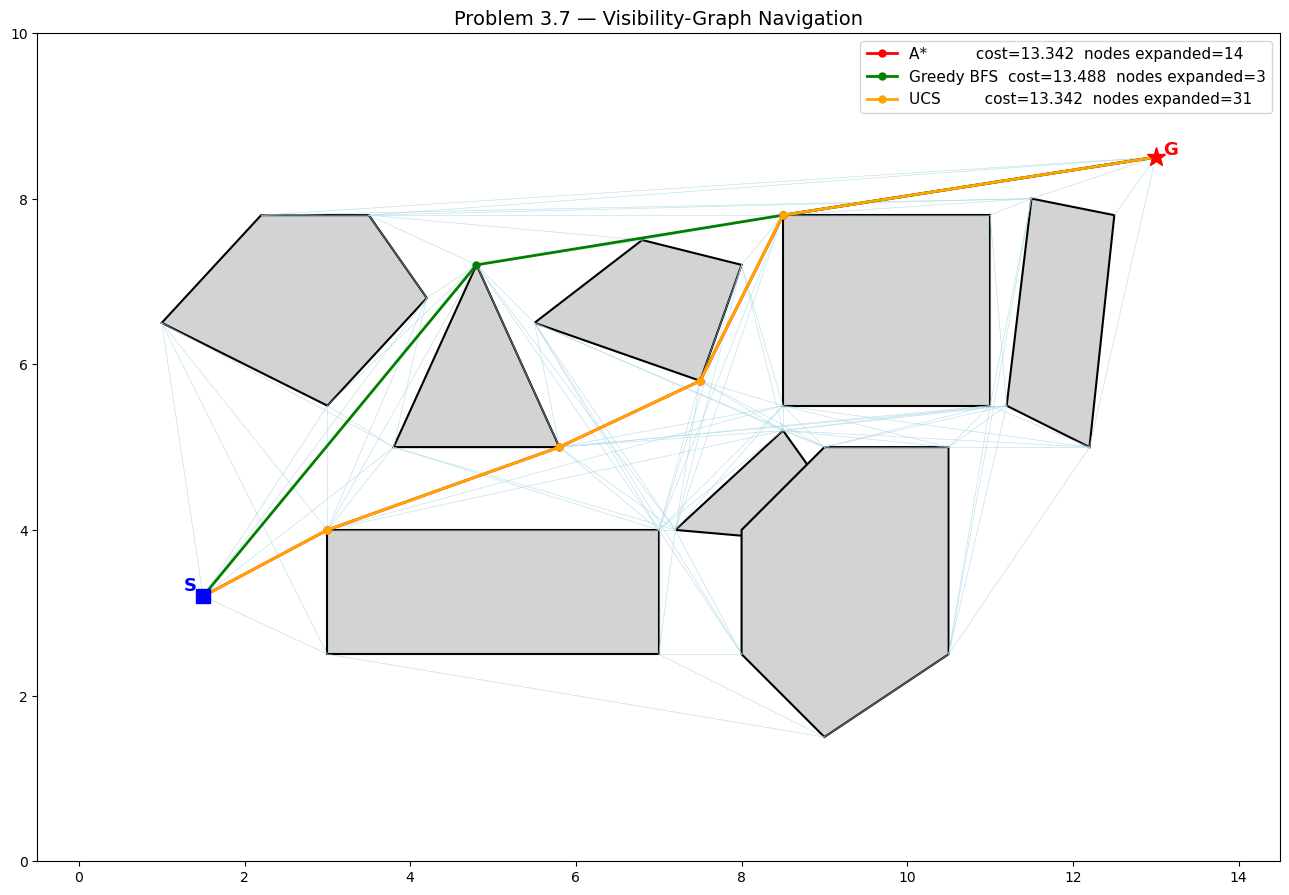

In [4]:
def draw_scene(polygons, start, goal, vis_graph, paths=None, labels=None, title=""):
    fig, ax = plt.subplots(figsize=(13, 9))
    for poly in polygons:
        ax.add_patch(MplPolygon(poly, closed=True, facecolor='lightgrey',
                                edgecolor='black', linewidth=1.5))
    for a in vis_graph:
        for b in vis_graph[a]:
            ax.plot([a[0],b[0]], [a[1],b[1]], color='lightblue',
                    linewidth=0.4, alpha=0.5, zorder=1)
    colours = ['red', 'green', 'orange']
    if paths:
        for path, colour, label in zip(paths, colours, labels or ['']*len(paths)):
            xs = [p[0] for p in path]; ys = [p[1] for p in path]
            ax.plot(xs, ys, '-o', color=colour, linewidth=2,
                    markersize=5, zorder=3, label=label)
    ax.plot(*start, 'bs', markersize=10, zorder=4)
    ax.annotate('S', start, textcoords='offset points', xytext=(-14,4),
                fontsize=13, fontweight='bold', color='blue')
    ax.plot(*goal, 'r*', markersize=14, zorder=4)
    ax.annotate('G', goal, textcoords='offset points', xytext=(5,2),
                fontsize=13, fontweight='bold', color='red')
    ax.set_xlim(-0.5, 14.5); ax.set_ylim(0, 10)
    ax.set_aspect('equal'); ax.set_title(title, fontsize=14)
    if paths: ax.legend(fontsize=11)
    plt.tight_layout(); plt.show()


draw_scene(
    POLYGONS, START, GOAL, vis_graph,
    paths  = [path_astar, path_greedy, path_ucs],
    labels = [f"A*          cost={cost_astar:.3f}  nodes expanded={exp_astar}",
              f"Greedy BFS  cost={cost_greedy:.3f}  nodes expanded={exp_greedy}",
              f"UCS         cost={cost_ucs:.3f}  nodes expanded={exp_ucs}"],
    title  = "Problem 3.7 — Visibility-Graph Navigation"
)


## Part (d) — Performance Analysis

The numbers in the table below come from the execution above and reflect the current graph.

| Algorithm | Path cost | Nodes expanded | Optimal? |
|---|---|---|---|
| **A\*** | 13.342 | 14 | Yes |
| **Greedy BFS** | 13.488 | 3 | No |
| **UCS** | 13.342 | 31 | Yes |

**Key observations:**

- **A\* and UCS** both find the true shortest path (cost ≈ 13.342). They are guaranteed optimal
  because UCS explores in order of accumulated cost, and A\* uses an admissible, consistent
  heuristic that never overestimates the remaining distance.

- **Greedy BFS** expands only 3 nodes — the fewest of the three — but produces a longer path
  (13.488). The reason: Greedy chooses each next node based solely on straight-line proximity
  to G, ignoring how much the path has already cost. This can lead it down a locally promising
  direction that is not globally optimal. It is fast, but sacrifices correctness.

- **A\* expands only 14 nodes** compared to UCS's 31. The straight-line heuristic provides
  tight guidance toward G, pruning roughly half the search effort while still guaranteeing
  the optimal answer. This is the main practical advantage of A\* over UCS in geometric
  navigation tasks.

- For safety-critical robot navigation, Greedy BFS is generally unacceptable. A\* is the
  preferred algorithm: it matches UCS on solution quality while being significantly faster.


---
---

# Problem 3.9 — Missionaries and Cannibals

**Russell & Norvig, 3rd ed. Problem 3.9** (4th ed. 3.11)

> Three missionaries and three cannibals are on one side of a river, along with a boat
> that can hold one or two people. Find a way to get everyone to the other side without
> ever leaving a group of missionaries in one place outnumbered by the cannibals in that
> place. (Amarel, 1968)


---
## Part (a) — Precise Problem Formulation and Complete State-Space Diagram

### State Representation

We track only what remains on the **left (start) bank** plus the **boat position**,
using a triple **(m, c, b)** where:

| Symbol | Meaning | Range |
|---|---|---|
| m | missionaries on the **left** bank | 0 – 3 |
| c | cannibals on the **left** bank | 0 – 3 |
| b | boat location: **1 = left bank, 0 = right bank** | {0, 1} |

The right-bank counts follow by subtraction: right missionaries = 3 − m, right cannibals = 3 − c.
The boat location b = 1 means the boat is on the left bank; b = 0 means it is on the right bank.
This convention is used uniformly throughout the formulation, code, diagrams, and solution trace.

**Initial state:** (3, 3, 1) — all six people and the boat on the left bank.

**Goal state:** (0, 0, 0) — all six people and the boat on the right bank.

### Safety Constraint

A state (m, c, b) is **valid** if and only if missionaries are not outnumbered on either bank
(unless there are zero missionaries on that bank):

- Left bank safe: m = 0  OR  m ≥ c
- Right bank safe: (3−m) = 0  OR  (3−m) ≥ (3−c)

### Actions

The boat carries 1 or 2 people per crossing. The five possible loads are:

| Action | Passengers |
|---|---|
| (1M, 0C) | 1 missionary |
| (0M, 1C) | 1 cannibal |
| (1M, 1C) | 1 missionary + 1 cannibal |
| (2M, 0C) | 2 missionaries |
| (0M, 2C) | 2 cannibals |

- When b = 1 (boat on left), these passengers move **right**: m decreases, c decreases, b → 0.
- When b = 0 (boat on right), these passengers move **left**: m increases, c increases, b → 1.

The resulting state is only accepted if it satisfies the safety constraint.

### State Space

There are at most 4 × 4 × 2 = 32 possible (m, c, b) triples. After applying the
safety constraint the code identifies **20 valid states** — every triple satisfying the
constraint, regardless of reachability from (3, 3, 1). This is the **complete state space**
required by the problem. From that set the code also identifies the **16 reachable states**
— the subset actually reachable through legal moves. The diagram below shows all 20 valid
states; unreachable-but-valid states are shown in grey to make the distinction visible.


In [5]:
from collections import deque

# ── Safety check ─────────────────────────────────────────────────

def is_valid(m, c):
    """
    True if the configuration (m missionaries, c cannibals on left bank)
    is safe on both banks.  m,c must already be in [0,3].
    """
    if not (0 <= m <= 3 and 0 <= c <= 3):
        return False
    left_ok  = (m == 0) or (m >= c)
    right_ok = ((3-m) == 0) or ((3-m) >= (3-c))
    return left_ok and right_ok

# ── All valid states (safety constraint only, no reachability check) ──

all_valid = [(m, c, b)
             for m in range(4)
             for c in range(4)
             for b in range(2)
             if is_valid(m, c)]

print(f"Total valid states (safety constraint): {len(all_valid)}")

# ── ACTIONS and RESULT ────────────────────────────────────────────

MOVES = [(1,0),(0,1),(1,1),(2,0),(0,2)]   # (missionaries, cannibals) to move

def successors(state):
    """
    Return list of (action_label, next_state) from state.
    Convention: b=1 means boat is on LEFT; b=0 means boat is on RIGHT.
    When b=1 the boat moves passengers to the right (→).
    When b=0 the boat brings passengers back to the left (←).
    """
    m, c, b = state
    result = []
    if b == 1:                             # boat on LEFT → move passengers right
        for dm, dc in MOVES:
            nm, nc = m - dm, c - dc
            if is_valid(nm, nc):
                label = f"-> ({dm}M,{dc}C)"
                result.append((label, (nm, nc, 0)))
    else:                                  # boat on RIGHT → bring passengers left
        for dm, dc in MOVES:
            nm, nc = m + dm, c + dc
            if is_valid(nm, nc):
                label = f"<- ({dm}M,{dc}C)"
                result.append((label, (nm, nc, 1)))
    return result

# ── Reachable states (BFS from initial) ─────────────────────────

INITIAL = (3, 3, 1)
GOAL    = (0, 0, 0)

def find_reachable(initial):
    visited = {initial}
    queue   = deque([initial])
    while queue:
        s = queue.popleft()
        for _, ns in successors(s):
            if ns not in visited:
                visited.add(ns)
                queue.append(ns)
    return visited

reachable = find_reachable(INITIAL)

print(f"Reachable states from {INITIAL}     : {len(reachable)}")
print()
print("States that are valid but NOT reachable from the initial state:")
unreachable_valid = [s for s in all_valid if s not in reachable]
for s in sorted(unreachable_valid):
    print(f"  {s}")
print()
print("All reachable states:")
for s in sorted(reachable):
    tag = ""
    if s == INITIAL: tag = "  <- INITIAL"
    if s == GOAL:    tag = "  <- GOAL"
    print(f"  {s}{tag}")


Total valid states (safety constraint): 20
Reachable states from (3, 3, 1)     : 16

States that are valid but NOT reachable from the initial state:
  (0, 0, 1)
  (0, 3, 0)
  (3, 0, 1)
  (3, 3, 0)

All reachable states:
  (0, 0, 0)  <- GOAL
  (0, 1, 0)
  (0, 1, 1)
  (0, 2, 0)
  (0, 2, 1)
  (0, 3, 1)
  (1, 1, 0)
  (1, 1, 1)
  (2, 2, 0)
  (2, 2, 1)
  (3, 0, 0)
  (3, 1, 0)
  (3, 1, 1)
  (3, 2, 0)
  (3, 2, 1)
  (3, 3, 1)  <- INITIAL


In [6]:
# ── State-space adjacency list (reachable states only) ──────────

print("State-space adjacency (reachable states, both directions listed):")
print("Convention: b=1 → boat on LEFT bank, b=0 → boat on RIGHT bank")
print()
for s in sorted(reachable):
    succs = successors(s)
    if succs:
        lines = [f"{a:14s} -> {ns}" for a, ns in succs]
        print(f"  {s}:  " + ("  |  ".join(lines)))


State-space adjacency (reachable states, both directions listed):
Convention: b=1 → boat on LEFT bank, b=0 → boat on RIGHT bank

  (0, 0, 0):  <- (0M,1C)     -> (0, 1, 1)  |  <- (1M,1C)     -> (1, 1, 1)  |  <- (0M,2C)     -> (0, 2, 1)
  (0, 1, 0):  <- (1M,0C)     -> (1, 1, 1)  |  <- (0M,1C)     -> (0, 2, 1)  |  <- (0M,2C)     -> (0, 3, 1)
  (0, 1, 1):  -> (0M,1C)     -> (0, 0, 0)
  (0, 2, 0):  <- (0M,1C)     -> (0, 3, 1)  |  <- (2M,0C)     -> (2, 2, 1)
  (0, 2, 1):  -> (0M,1C)     -> (0, 1, 0)  |  -> (0M,2C)     -> (0, 0, 0)
  (0, 3, 1):  -> (0M,1C)     -> (0, 2, 0)  |  -> (0M,2C)     -> (0, 1, 0)
  (1, 1, 0):  <- (1M,1C)     -> (2, 2, 1)  |  <- (2M,0C)     -> (3, 1, 1)
  (1, 1, 1):  -> (1M,0C)     -> (0, 1, 0)  |  -> (1M,1C)     -> (0, 0, 0)
  (2, 2, 0):  <- (1M,0C)     -> (3, 2, 1)  |  <- (1M,1C)     -> (3, 3, 1)
  (2, 2, 1):  -> (1M,1C)     -> (1, 1, 0)  |  -> (2M,0C)     -> (0, 2, 0)
  (3, 0, 0):  <- (0M,1C)     -> (3, 1, 1)  |  <- (0M,2C)     -> (3, 2, 1)
  (3, 1, 0):  <- (0M,1C) 

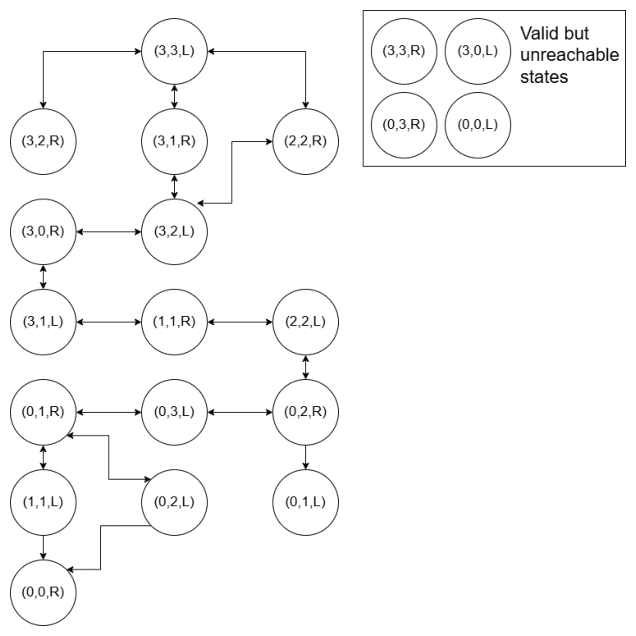

Complete state space : 20 valid states
  Reachable from (3, 3, 1): 16
  Valid but unreachable   : 4


In [8]:
from PIL import Image
import matplotlib.pyplot as plt
from collections import deque

# ── Problem definition — Missionaries and Cannibals ─────────────

INITIAL = (3, 3, 1)
GOAL = (0, 0, 0)

# ── Action model (boat moves) ───────────────────────────────────
#
# The boat can carry:
#   (1,0) → 1 missionary
#   (2,0) → 2 missionaries
#   (0,1) → 1 cannibal
#   (0,2) → 2 cannibals
#   (1,1) → 1 missionary and 1 cannibal

ACTIONS = [(1,0), (2,0), (0,1), (0,2), (1,1)]

# ── State validity function ─────────────────────────────────────
#
# Returns True if the state satisfies:
#   - 0 ≤ M_L, C_L ≤ 3
#   - On each bank, if missionaries are present,
#     they cannot be outnumbered by cannibals

def is_valid(m, c):
    if m < 0 or m > 3 or c < 0 or c > 3:
        return False
    if m > 0 and c > m:
        return False
    if (3-m) > 0 and (3-c) > (3-m):
        return False
    return True

# ── Successor function ──────────────────────────────────────────

def successors(state):
    m, c, b = state
    result = []

    for dm, dc in ACTIONS:
        if b == 1:  # left → right
            new = (m - dm, c - dc, 0)
        else:       # right → left
            new = (m + dm, c + dc, 1)

        nm, nc, nb = new

        # check availability of people on the departing side
        if b == 1:
            if m < dm or c < dc:
                continue
        else:
            if (3 - m) < dm or (3 - c) < dc:
                continue

        if is_valid(nm, nc):
            result.append(new)

    return result

# ── Complete state space (all valid states) ─────────────────────

all_valid_states = [
    (m, c, b)
    for m in range(4)
    for c in range(4)
    for b in [0,1]
    if is_valid(m, c)
]

# ── Reachable state space (BFS) ─────────────────────────────────

def bfs(start):
    visited = set()
    queue = deque([start])

    while queue:
        s = queue.popleft()
        if s in visited:
            continue
        visited.add(s)

        for nxt in successors(s):
            if nxt not in visited:
                queue.append(nxt)

    return visited

reachable = bfs(INITIAL)

# ── Image display (final diagram) ───────────────────────────────

img = Image.open("Complete State Diagram.png")

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

# ── Output summary ──────────────────────────────────────────────
#
# Prints:
#   - Total number of valid states (complete state space)
#   - Number of reachable states from the initial state
#   - Number of valid but unreachable states
#
# Expected output:
#   Complete state space : 20 valid states
#     Reachable from (3, 3, 1): 16
#     Valid but unreachable   : 4

print(f"Complete state space : {len(all_valid_states)} valid states")
print(f"  Reachable from {INITIAL}: {len(reachable)}")
print(f"  Valid but unreachable   : {len(all_valid_states) - len(reachable)}")

---
## Part (b) — Optimal Solution via BFS; Should We Check for Repeated States?

### Algorithm Choice and Optimality

**Breadth-First Search (BFS)** is the natural algorithm for this problem because every boat
crossing has the same unit cost (one trip). This means:

- Every action has cost 1.
- Minimising the number of crossings is identical to minimising total path cost.
- BFS always expands nodes in order of depth (number of actions from the start), so the
  first time it reaches the goal it has found a **path with the fewest crossings**, which
  is therefore the **cost-optimal solution**.

If crossings had different costs (e.g., two people tire the boat more), we would need UCS
instead. Here, uniform costs make BFS sufficient and correct.

### Should We Check for Repeated States? Yes, Absolutely.

The state space contains **cycles**: for example, sending 1 missionary across and bringing
1 back returns to the initial state. Without a visited set, BFS would enter these cycles
and loop indefinitely, never reaching the goal. Maintaining a visited set:

- **Guarantees termination** — the space has only 12 reachable states.
- **Keeps BFS correct** — each state is expanded at most once.
- **Has negligible cost** — the state space is tiny (≤ 12 states), so the set never grows
  large.

The cost of checking the visited set is O(1) per lookup; the benefit is correctness.
Omitting it would turn a tractable search into an infinite loop.


In [8]:
def bfs_solve(initial, goal):
    """
    BFS with repeated-state checking.
    Returns (final_state, list_of_(action, state) steps).
    """
    # Each frontier entry: (current_state, path_so_far)
    frontier = deque([(initial, [])])
    visited  = {initial}

    while frontier:
        state, path = frontier.popleft()
        if state == goal:
            return state, path
        for action, next_state in successors(state):
            if next_state not in visited:
                visited.add(next_state)
                frontier.append((next_state, path + [(action, next_state)]))

    return None, []   # no solution found


final_state, solution = bfs_solve(INITIAL, GOAL)

# ── Print solution trace ─────────────────────────────────────────

def fmt_state(m, c, b):
    rm, rc = 3-m, 3-c
    boat = "LEFT" if b == 1 else "RIGHT"
    return (f"left({m}M,{c}C) | right({rm}M,{rc}C) | boat:{boat}")

print("=" * 65)
print("OPTIMAL SOLUTION — BFS with repeated-state checking")
print("=" * 65)
print()
print(f"  Step  0 [start]:  {fmt_state(*INITIAL)}   state={INITIAL}")
for step, (action, state) in enumerate(solution, 1):
    m, c, b = state
    print(f"  Step {step:2d} [{action}]:  {fmt_state(m,c,b)}   state={state}")
print()
print(f"Goal {GOAL} reached in {len(solution)} crossings.  Solution is optimal (BFS + uniform cost).")


OPTIMAL SOLUTION — BFS with repeated-state checking

  Step  0 [start]:  left(3M,3C) | right(0M,0C) | boat:LEFT   state=(3, 3, 1)
  Step  1 [-> (1M,1C)]:  left(2M,2C) | right(1M,1C) | boat:RIGHT   state=(2, 2, 0)
  Step  2 [<- (1M,0C)]:  left(3M,2C) | right(0M,1C) | boat:LEFT   state=(3, 2, 1)
  Step  3 [-> (0M,2C)]:  left(3M,0C) | right(0M,3C) | boat:RIGHT   state=(3, 0, 0)
  Step  4 [<- (0M,1C)]:  left(3M,1C) | right(0M,2C) | boat:LEFT   state=(3, 1, 1)
  Step  5 [-> (2M,0C)]:  left(1M,1C) | right(2M,2C) | boat:RIGHT   state=(1, 1, 0)
  Step  6 [<- (1M,1C)]:  left(2M,2C) | right(1M,1C) | boat:LEFT   state=(2, 2, 1)
  Step  7 [-> (2M,0C)]:  left(0M,2C) | right(3M,1C) | boat:RIGHT   state=(0, 2, 0)
  Step  8 [<- (0M,1C)]:  left(0M,3C) | right(3M,0C) | boat:LEFT   state=(0, 3, 1)
  Step  9 [-> (0M,2C)]:  left(0M,1C) | right(3M,2C) | boat:RIGHT   state=(0, 1, 0)
  Step 10 [<- (1M,0C)]:  left(1M,1C) | right(2M,2C) | boat:LEFT   state=(1, 1, 1)
  Step 11 [-> (1M,1C)]:  left(0M,0C) | right(

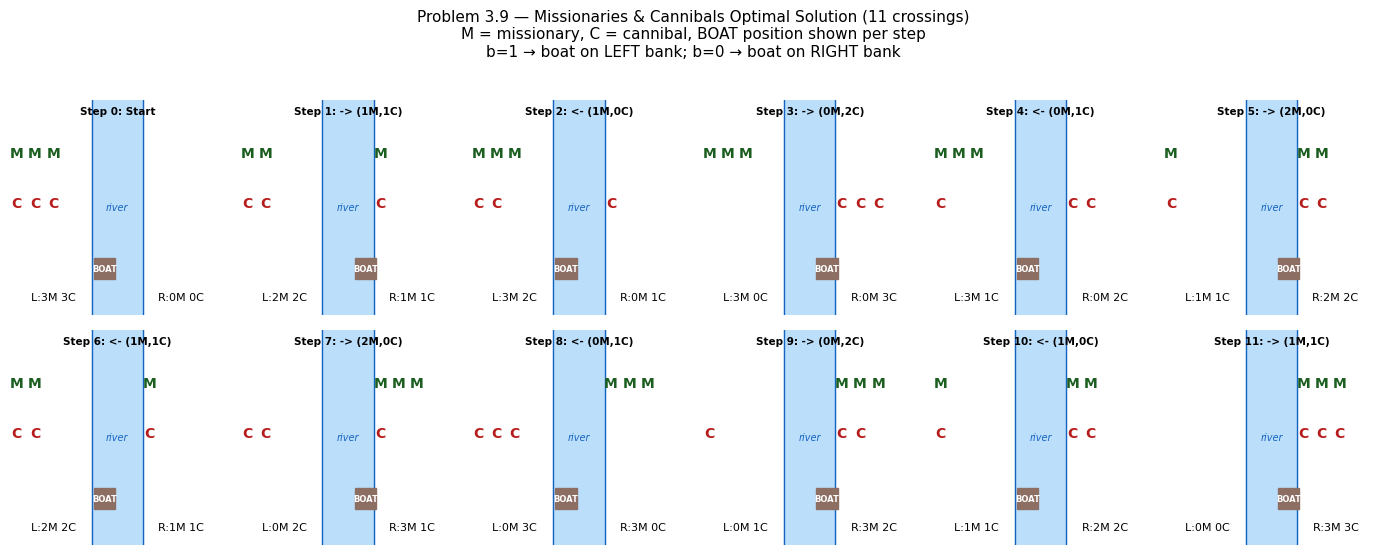

In [9]:
# ── Visualise each step ──────────────────────────────────────────

def draw_crossing(ax, state, action_label, step_idx):
    """Draw one river-crossing step in the given Axes."""
    m, c, b = state
    rm, rc  = 3-m, 3-c

    ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis('off')

    # River background
    ax.add_patch(plt.Rectangle((3.8, 0), 2.4, 6, color='#bbdefb', zorder=0))
    ax.axvline(3.8, color='#1565c0', lw=1)
    ax.axvline(6.2, color='#1565c0', lw=1)
    ax.text(5, 3, "river", ha='center', va='center',
            fontsize=7, color='#1565c0', style='italic')

    # Left-bank people
    for i in range(m):
        ax.text(0.3+i*0.85, 4.4, "M", ha='center',
                fontsize=10, fontweight='bold', color='#1b5e20')
    for i in range(c):
        ax.text(0.3+i*0.85, 3.0, "C", ha='center',
                fontsize=10, fontweight='bold', color='#b71c1c')

    # Right-bank people
    for i in range(rm):
        ax.text(6.5+i*0.85, 4.4, "M", ha='center',
                fontsize=10, fontweight='bold', color='#1b5e20')
    for i in range(rc):
        ax.text(6.5+i*0.85, 3.0, "C", ha='center',
                fontsize=10, fontweight='bold', color='#b71c1c')

    # Boat (b=1 → left bank; b=0 → right bank)
    bx = 3.9 if b == 1 else 5.3
    ax.add_patch(plt.Rectangle((bx, 1.0), 1.0, 0.6, color='#8d6e63', zorder=2))
    ax.text(bx+0.5, 1.3, "BOAT", ha='center', va='center',
            fontsize=6, color='white', fontweight='bold')

    ax.text(5, 5.6, f"Step {step_idx}: {action_label}",
            ha='center', fontsize=7.5, fontweight='bold')
    ax.text(2.0, 0.4, f"L:{m}M {c}C", ha='center', fontsize=8)
    ax.text(8.0, 0.4, f"R:{rm}M {rc}C", ha='center', fontsize=8)


all_steps = [(INITIAL, "Start")] + [(ns, a) for a, ns in solution]
n = len(all_steps)
cols = 6
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, rows*2.7))
axes = axes.flatten()

for idx, (state, action) in enumerate(all_steps):
    draw_crossing(axes[idx], state, action, idx)

for idx in range(n, len(axes)):
    axes[idx].axis('off')

fig.suptitle(
    f"Problem 3.9 — Missionaries & Cannibals Optimal Solution ({len(solution)} crossings)\n"
    "M = missionary, C = cannibal, BOAT position shown per step\n"
    "b=1 → boat on LEFT bank; b=0 → boat on RIGHT bank",
    fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


---
## Part (c) — Why Do Humans Find This Puzzle Hard?

Despite the state space having only **16 reachable states** and a solution requiring just
**11 crossings**, humans consistently struggle with this puzzle. Several well-studied
cognitive factors explain this:

### 1. Counter-intuitive "backward" moves are required
The optimal solution includes steps where people are *returned* to the start bank (e.g.,
Step 6: ← (1M, 1C)). This violates the natural human heuristic of *always making visible
progress toward the goal*. People tend to reject moves that look like regression, even when
they are necessary to avoid a dead end later.

### 2. Working-memory demands exceed typical human capacity
Correctly evaluating a state requires checking four counts simultaneously (left missionaries,
left cannibals, right missionaries, right cannibals) against two asymmetric safety constraints.
Human working memory is limited to roughly 7 ± 2 independent items; tracking all four counts
plus the boat position, while mentally simulating a proposed move, pushes against this limit.

### 3. Cycles and dead ends without systematic backtracking
Several reachable states look "almost solved" but lead only to previously visited states or
dead ends. Humans typically do not backtrack in a disciplined way (the way BFS does with a
visited set); they tend to restart from scratch when stuck, losing earlier progress.

### 4. No intuitive analogy or memorisable pattern
Familiar puzzles (Tower of Hanoi, 8-puzzle) have a structural pattern that can be verbalised
or visualised. The safety constraint here — "missionaries must not be outnumbered unless
there are none" — is domain-specific and provides no such grip. Without a familiar template
to map onto, each move must be reasoned out from scratch.

### 5. State space appears larger than it is
Without formal analysis, people do not realise the problem has only 12 reachable states.
The impression of an open-ended search space leads to premature abandonment.

### Summary
The puzzle is hard for humans because it *requires systematic search with backtracking*,
*violates progress-based intuition*, and *imposes high working-memory demands* — exactly
the conditions where exhaustive algorithmic search (BFS) excels and human heuristic
reasoning fails.
